In [ ]:
# taken from vist-diffusion-pinn-5200-half-channel-plus-units-load-skip-5-cells.py

import numpy as np
from numpy import linalg as LA
import math as m
import os
import sys
from matplotlib.image import imread
import matplotlib.pyplot as plt
from matplotlib import rcParams # for changing default values
import scipy.io as sio
from scipy.optimize import minimize
import timeit
import torch
import random
import torch.nn as nn
import torch.optim as optim
from scipy.integrate import odeint
from torch.autograd import grad
import torch.optim.lr_scheduler as lr_scheduler

plt.close('all')
plt.interactive(True)
# set all fontsizes 
rcParams["font.size"] = 16

viscos = 1/2000

# load DNS data

DNS_mean=np.genfromtxt("Re2000_jimenez.dat",comments="%") # Can use jiminez 2000
y_DNS=DNS_mean[:,0];
yplus_DNS=DNS_mean[:,1];
u_DNS=DNS_mean[:,2];
dudy_DNS=np.gradient(u_DNS,yplus_DNS)


DNS_stress=np.genfromtxt("Re2000_jimenez.dat",comments="%") #Also jiminewz 2000
u2_DNS=(DNS_stress[:,3])**2;
v2_DNS=(DNS_stress[:,4])**2;
w2_DNS=(DNS_stress[:,5])**2;
uv_DNS=DNS_stress[:,10];
k_DNS=0.5*(u2_DNS+v2_DNS+w2_DNS)
dkdy_DNS=np.gradient(k_DNS,yplus_DNS,edge_order=2)
d2kdy2_DNS=np.gradient(dkdy_DNS,yplus_DNS,edge_order=2)

DNS_k_terms=np.genfromtxt("Re2000_bal_k.dat",comments="%")

diss_DNS=DNS_k_terms[:,2]
Pk_DNS=DNS_k_terms[:,3]
diff_DNS=DNS_k_terms[:,6]
diff_DNS_visc=DNS_k_terms[:,7]

diss_DNS=diss_DNS
Pk_DNS=Pk_DNS
diff_DNS=diff_DNS
diff_DNS_visc = diff_DNS_visc


vist_DNS = np.abs(uv_DNS/dudy_DNS)


# load k-omega grid
kom_data = np.loadtxt('y_u_k_om_uv_2000-RANS-half-channel.txt')
y_kom = kom_data[:,0]
k_kom = kom_data[:,2]
om_kom = kom_data[:,3]
vist_kom = k_kom/om_kom/viscos

# skip 5 cells near the wall
j=5
y_kom = y_kom[j:]
vist_kom = vist_kom[j:]

nj = len(y_kom)

viscos_lam = np.ones(nj)

k_DNS = np.interp(y_kom, y_DNS, k_DNS)
k_DNS = torch.tensor(k_DNS, requires_grad=True, dtype=torch.float32).view((-1, 1))

Pk_DNS = np.interp(y_kom, y_DNS, Pk_DNS)
Pk_DNS = torch.tensor(Pk_DNS, requires_grad=True, dtype=torch.float32).view((-1, 1))

diss_DNS = np.interp(y_kom, y_DNS, diss_DNS)
diss_DNS = torch.tensor(diss_DNS, requires_grad=True, dtype=torch.float32).view((-1, 1))

d2kdy2_DNS = np.interp(y_kom, y_DNS, d2kdy2_DNS)
d2kdy2_DNS = torch.tensor(d2kdy2_DNS, requires_grad=True, dtype=torch.float32).view((-1, 1))

dkdy_DNS = np.interp(y_kom, y_DNS, dkdy_DNS)
dkdy_DNS = torch.tensor(dkdy_DNS, requires_grad=True, dtype=torch.float32).view((-1, 1))

diff_DNS_visc = np.interp(y_kom, y_DNS, diff_DNS_visc)

diff_DNS = np.interp(y_kom, y_DNS, diff_DNS)
diff_DNS = torch.tensor(diff_DNS, requires_grad=True, dtype=torch.float32).view((-1, 1))
print(diff_DNS)

vist_DNS = np.interp(y_kom, y_DNS, vist_DNS)
vist_DNS_np = vist_DNS
vist_DNS = torch.tensor(vist_DNS, requires_grad=True, dtype=torch.float32).view((-1, 1))

viscos_lam = torch.tensor(viscos_lam, requires_grad=True, dtype=torch.float32).view((-1, 1))

# yplus_DNS = np.interp(y_kom, y_DNS, yplus_DNS)
# yplus_DNS_np = yplus_DNS
# yplus_DNS = torch.tensor(yplus_DNS, requires_grad=True, dtype=torch.float32).view((-1, 1))

# y_DNS = torch.tensor(y_kom, requires_grad=True, dtype=torch.float32).view((-1, 1))

# Interpolate yplus_DNS onto the RANS grid
yplus_DNS = np.interp(y_kom, y_DNS, yplus_DNS)
yplus_DNS_np = yplus_DNS

# --- Normalize y⁺ between 0 and 1 ---
y_min = yplus_DNS_np.min()
y_max = yplus_DNS_np.max()
yplus_DNS_norm_np = (yplus_DNS_np - y_min) / (y_max - y_min)

# Convert to torch tensor (normalized)
yplus_DNS = torch.tensor(yplus_DNS_norm_np, requires_grad=True, dtype=torch.float32).view((-1, 1))

# b.c.
vist_0 = vist_DNS[0]
vist_1 = vist_DNS[-1]

y = yplus_DNS


In [ ]:
# taken from vist-diffusion-pinn-5200-half-channel-plus-units-load-skip-5-cells.py

import numpy as np
from numpy import linalg as LA
import math as m
import os
import sys
from matplotlib.image import imread
import matplotlib.pyplot as plt
from matplotlib import rcParams # for changing default values
import scipy.io as sio
from scipy.optimize import minimize
import timeit
import torch
import random
import torch.nn as nn
import torch.optim as optim
from scipy.integrate import odeint
from torch.autograd import grad
import torch.optim.lr_scheduler as lr_scheduler

plt.close('all')
plt.interactive(True)
# set all fontsizes 
rcParams["font.size"] = 16

viscos = 1/2000

# load DNS data

DNS_mean=np.genfromtxt("Re2000_jimenez.dat",comments="%") # Can use jiminez 2000
y_DNS=DNS_mean[:,0];
yplus_DNS=DNS_mean[:,1];
u_DNS=DNS_mean[:,2];
dudy_DNS=np.gradient(u_DNS,yplus_DNS)


DNS_stress=np.genfromtxt("Re2000_jimenez.dat",comments="%") #Also jiminewz 2000
u2_DNS=(DNS_stress[:,3])**2;
v2_DNS=(DNS_stress[:,4])**2;
w2_DNS=(DNS_stress[:,5])**2;
uv_DNS=DNS_stress[:,10];
k_DNS=0.5*(u2_DNS+v2_DNS+w2_DNS)
dkdy_DNS=np.gradient(k_DNS,yplus_DNS,edge_order=2)
d2kdy2_DNS=np.gradient(dkdy_DNS,yplus_DNS,edge_order=2)

DNS_k_terms=np.genfromtxt("Re2000_bal_k.dat",comments="%")

diss_DNS=DNS_k_terms[:,2]
Pk_DNS=DNS_k_terms[:,3]
diff_DNS=DNS_k_terms[:,6]
diff_DNS_visc=DNS_k_terms[:,7]

diss_DNS=diss_DNS
Pk_DNS=Pk_DNS
diff_DNS=diff_DNS
diff_DNS_visc = diff_DNS_visc


vist_DNS = np.abs(uv_DNS/dudy_DNS)


# load k-omega grid
kom_data = np.loadtxt('y_u_k_om_uv_2000-RANS-half-channel.txt')
y_kom = kom_data[:,0]
k_kom = kom_data[:,2]
om_kom = kom_data[:,3]
vist_kom = k_kom/om_kom/viscos

# skip 5 cells near the wall
j=5
y_kom = y_kom[j:]
vist_kom = vist_kom[j:]

nj = len(y_kom)

viscos_lam = np.ones(nj)

k_DNS = np.interp(y_kom, y_DNS, k_DNS)
k_DNS = torch.tensor(k_DNS, requires_grad=True, dtype=torch.float32).view((-1, 1))

Pk_DNS = np.interp(y_kom, y_DNS, Pk_DNS)
Pk_DNS = torch.tensor(Pk_DNS, requires_grad=False, dtype=torch.float32).view((-1, 1))

diss_DNS = np.interp(y_kom, y_DNS, diss_DNS)
diss_DNS = torch.tensor(diss_DNS, requires_grad=True, dtype=torch.float32).view((-1, 1))

d2kdy2_DNS = np.interp(y_kom, y_DNS, d2kdy2_DNS)
d2kdy2_DNS = torch.tensor(d2kdy2_DNS, requires_grad=True, dtype=torch.float32).view((-1, 1))

dkdy_DNS = np.interp(y_kom, y_DNS, dkdy_DNS)
dkdy_DNS = torch.tensor(dkdy_DNS, requires_grad=True, dtype=torch.float32).view((-1, 1))

diff_DNS_visc = np.interp(y_kom, y_DNS, diff_DNS_visc)

diff_DNS = np.interp(y_kom, y_DNS, diff_DNS)
diff_DNS = torch.tensor(diff_DNS, requires_grad=True, dtype=torch.float32).view((-1, 1))

vist_DNS = np.interp(y_kom, y_DNS, vist_DNS)
vist_DNS_np = vist_DNS
vist_DNS = torch.tensor(vist_DNS, requires_grad=True, dtype=torch.float32).view((-1, 1))

viscos_lam = torch.tensor(viscos_lam, requires_grad=True, dtype=torch.float32).view((-1, 1))

# yplus_DNS = np.interp(y_kom, y_DNS, yplus_DNS)
# yplus_DNS_np = yplus_DNS
# yplus_DNS = torch.tensor(yplus_DNS, requires_grad=True, dtype=torch.float32).view((-1, 1))

# y_DNS = torch.tensor(y_kom, requires_grad=True, dtype=torch.float32).view((-1, 1))

# Interpolate yplus_DNS onto the RANS grid
yplus_DNS = np.interp(y_kom, y_DNS, yplus_DNS)
yplus_DNS_np = yplus_DNS

# --- Normalize y⁺ between 0 and 1 ---
y_min = yplus_DNS_np.min()
y_max = yplus_DNS_np.max()
yplus_DNS_norm_np = (yplus_DNS_np - y_min) / (y_max - y_min)

# Convert to torch tensor (normalized)
yplus_DNS = torch.tensor(yplus_DNS_norm_np, requires_grad=True, dtype=torch.float32).view((-1, 1))

# b.c.
vist_0 = vist_DNS[0]
vist_1 = vist_DNS[-1]

y = yplus_DNS

# Define get_derivative
dtype = torch.float
device = torch.device("cpu")

# def get_derivative(f, y):
#     """Compute the derivative of f = f(y) with respect to y."""
#     df_dy = grad(f, y, torch.ones(y.size()[0], 1, device=device), create_graph=True)[0]
#     return df_dy

y_scale = y_max - y_min

def get_derivative(f, y):
    df_dy = grad(f, y, torch.ones_like(y), create_graph=True)[0]
    # rescale back to physical gradient
    return df_dy / y_scale


class MyNet2(nn.Module):
  def __init__(self):
    super().__init__()
    self.ll1 = nn.Linear(in_features=1,out_features=16) # 1-32-64-32-1
    self.tanh = nn.Tanh()
    self.ll2 = nn.Linear(in_features=16,out_features=32)
    self.ll3 = nn.Linear(in_features=32,out_features=32)
    self.ll4 = nn.Linear(in_features=32,out_features=16)
    self.output = nn.Linear(in_features=16,out_features=1)

  def forward(self,x):
#       print('self',self)
        out = self.ll1(x)
        out = self.tanh(out)
        out = self.ll2(out)
        out = self.tanh(out)
        out = self.ll3(out)
        out = self.tanh(out)
        out = self.ll4(out)
        out = self.output(out)
        return out
    
# Create an instance 
model = MyNet2()

#%% Define loss function
def PDE(y, vist_pred):
        """Compute the cost function."""
        global temp
        # Differential equation loss
        dvist_dy = get_derivative( vist_pred,y)  
        temp = (vist_pred+viscos_lam) * d2kdy2_DNS + dkdy_DNS*dvist_dy

        boundary_condition_loss = 0
        differential_equation_loss = temp  + (Pk_DNS - diss_DNS)
        imbalance = differential_equation_loss
        differential_equation_loss = torch.sum(differential_equation_loss ** 2)
        # Boundary condition loss initialization
        boundary_condition_loss = 0
        # Sum over dirichlet boundary condition losses
        boundary_condition_loss += (vist_pred[0] - vist_0) ** 2
        boundary_condition_loss += (vist_pred[-1] - vist_1) ** 2
        loss_mse = torch.mean((vist_pred - vist_DNS)**2)
        
        return differential_equation_loss, boundary_condition_loss, imbalance, loss_mse

def loss_and_PDE(y_tensor):
    optimizer.zero_grad() # Clear gradients from the previous iteration
    outputs = model(y_tensor)  #get vist_t 
    loss_de,loss_bc, imbalance, loss_mse = PDE(y_tensor, outputs) # Compute the loss
    # loss = (1*loss_de+1000*loss_bc+loss_mse*100)/(1+1000+100) # [1 1000 100 + 0.1]
    loss = (1*loss_de+10*loss_bc+loss_mse*0)/100 # [1 1000 100 + 0.1]    
# Calculate the L1 regularization term
    l1_regularization = torch.tensor(0.)
    for param in model.parameters():
        l1_regularization += torch.norm(param, p=1)

    # Add the L1 regularization term to the loss
    lambda_l1=0.1
    loss += lambda_l1 * l1_regularization # Compute the loss
    loss.backward() # Compute gradients using backpropagation
    return loss,loss_de,loss_bc, imbalance, loss_mse

#%% training
prev_loss = float('inf')  # Initialize with a large value
max_no_epoch=250000 # try 750000
#max_no_epoch=2

optim_alg='Adam'
#optim_alg='SGD'
learning_rate = 0.2  #  4221.8496 milestones=[500000]
learning_rate = 0.2  #  0.6554632 milestones=[6400,43000,54578]
print('Adam taken')
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

#for saving training result
differential_equation_loss_history = np.zeros(max_no_epoch)
boundary_condition_loss_history = np.zeros(max_no_epoch)
mse_loss_history = np.zeros(max_no_epoch)
loss_min = 1e30
# Training loop
for epoch in range(max_no_epoch):
    loss,loss_de,loss_bc, imbalance, loss_mse = loss_and_PDE(y)
    differential_equation_loss_history[epoch] += loss_de
    boundary_condition_loss_history[epoch] += loss_bc
    mse_loss_history[epoch] += loss_mse
    optimizer.step()
    loss_change = prev_loss - loss
    prev_loss = loss

# Define checkpoint
    if epoch == 0:
       checkpoint = torch.load('checkpoint-vist-2000-plus-units-save-5-cells.ct')

# Apply the state_dict to model and optimizer
       model = MyNet2()  # Initialize model; Ensure it's the same architecture
       model.load_state_dict(checkpoint['model_state_dict'])

       optimizer = optim.Adam(model.parameters(), lr=learning_rate) # Initialize optimizer; Ensure it's the same optimizer type
       optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    #    scheduler = optim.lr_scheduler.MultiStepLR(optimizer,  milestones=[6400*max_no_epoch/1e5,16700*max_no_epoch/1e5,19200*max_no_epoch/1e5,37500*max_no_epoch/1e5,38000*max_no_epoch/1e5,80000*max_no_epoch/1e5,94000*max_no_epoch/1e5], gamma=0.5)
       scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',factor=0.5,patience=7500,verbose=True)
#milestones=[6400,16700,19200,37500,38000,80000,94000], gamma=1)
# Retrieve the training epoch
       epoch = checkpoint['epoch']
       loss = checkpoint['loss']

       model.train()  # For training mode (resuming training)

    scheduler.step(loss)

    loss_np = loss.detach().numpy()

# Print the loss every epoch
    loss_min = np.minimum(loss_np,loss_min)
    loss_min = np.float32(loss_min)
    torch.set_printoptions(precision=4)
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}, Learning Rate: {current_lr:.2e}, Loss: {loss_np[0]:.2e}, Loss_min: {loss_min[0]:.2e}")
    # print(f"Epoch {epoch+1}, Learning Rate: {scheduler.get_last_lr()[0]}, Loss: {loss_np[0]:.2e}, Loss_min: {loss_min[0]:.2e}")
    if loss_np < 5e-5:
        vist_pred = model(y)
        vist_pred_np =  vist_pred.detach().numpy()[:,0]

        print('break')

        break

Adam taken


RuntimeError: The size of tensor a (317) must match the size of tensor b (55) at non-singleton dimension 0

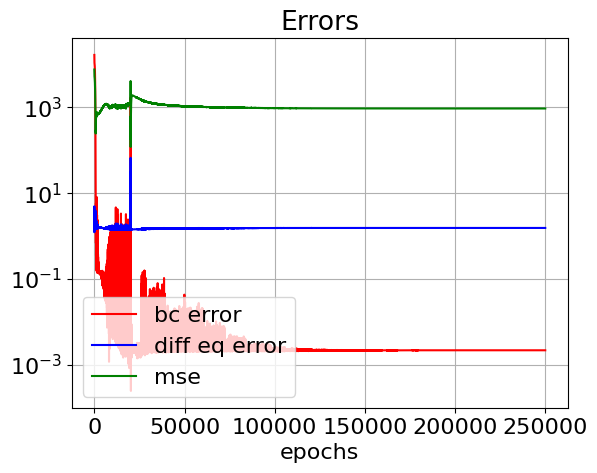

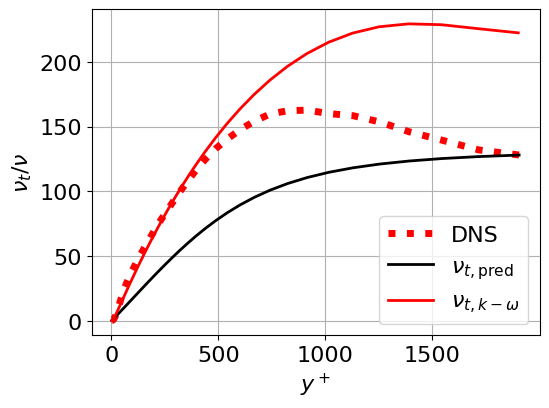

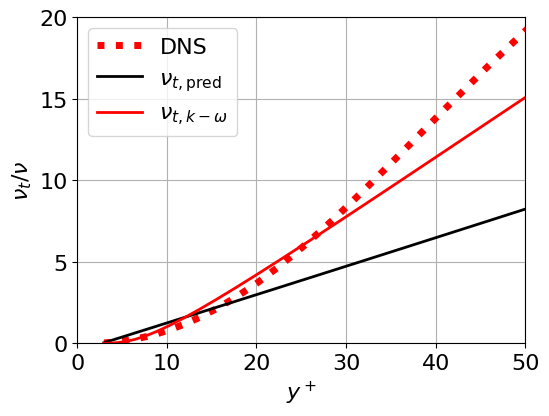

ValueError: when 1d, distances must match the length of the corresponding dimension

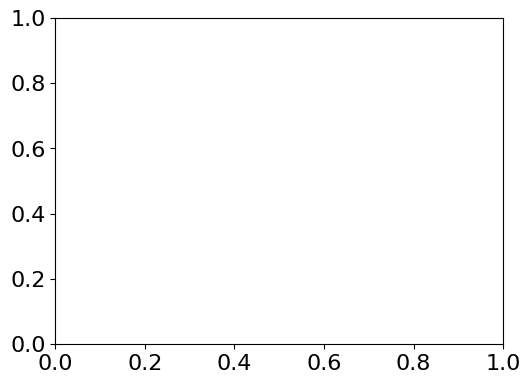

In [28]:
#%%
# Plot loss_function
fig, ax = plt.subplots(nrows=1, ncols=1) # Create a figure with one subplot
ax.semilogy(np.arange(len(boundary_condition_loss_history)), boundary_condition_loss_history,color='red', label='bc error')
ax.semilogy(np.arange(len(boundary_condition_loss_history)), differential_equation_loss_history,color='blue',label="diff eq error")
ax.semilogy(np.arange(len(boundary_condition_loss_history)), mse_loss_history,color='green', label='mse')

plt.xlabel(r'epochs')
ax.set_title(r'Errors')
ax.grid(visible=True)
ax.legend(loc='best') 
#plt.savefig('loss-half-5200-plus-units-load-5-cells.png',bbox_inches='tight')
plt.show()

######################## plot vist
fig, ax = plt.subplots(nrows=1, ncols=1) # Create a figure with one subplot
plt.subplots_adjust(left=0.20,bottom=0.20)
ax.plot(yplus_DNS_np, vist_DNS_np,color='r',linestyle=':',linewidth=5, label='DNS')
vist_pred = model(y) 
vist_pred_np =  vist_pred.detach().numpy()[:,0]
ax.plot(yplus_DNS_np, vist_pred_np,color='k',linestyle='-',linewidth=2, label=r"$\nu_{t,\mathrm{pred}}$")
ax.plot(y_kom/viscos, vist_kom,color='r',linestyle='-',linewidth=2, label=r"$\nu_{t,k-\omega}$")
ax.legend(loc='best') 
plt.xlabel('$y^+$')
plt.ylabel(r'$\nu_t/\nu$')   
#plt.xlim(0,100)
#ax.axis([0,50,0,20])
ax.grid(visible=True)
#plt.savefig('vist-PINN-5200-plus-units-load-5-cells-zoom.png',bbox_inches='tight')
plt.show()
np.savetxt('vist_pred-PINN-from-vist-diffusion-pinn-2000-plus-units-load-5-cells.txt',vist_pred_np)

######################## plot vist zoom
fig, ax = plt.subplots(nrows=1, ncols=1) # Create a figure with one subplot
plt.subplots_adjust(left=0.20,bottom=0.20)
ax.plot(yplus_DNS_np, vist_DNS_np,color='r',linestyle=':',linewidth=5, label='DNS')
vist_pred = model(y) 
vist_pred_np =  vist_pred.detach().numpy()[:,0]
ax.plot(yplus_DNS_np, vist_pred_np,color='k',linestyle='-',linewidth=2, label=r"$\nu_{t,\mathrm{pred}}$")
ax.plot(y_kom/viscos, vist_kom,color='r',linestyle='-',linewidth=2, label=r"$\nu_{t,k-\omega}$")
ax.legend(loc='best') 
plt.xlabel('$y^+$')
plt.ylabel(r'$\nu_t/\nu$')   
plt.xlim(0,100)
ax.axis([0,50,0,20])
ax.grid(visible=True)
#plt.savefig('vist-PINN-5200-plus-units-load-5-cells-zoom.png',bbox_inches='tight')
plt.show()
np.savetxt('vist_pred-PINN-from-vist-diffusion-pinn-2000-plus-units-load-5-cells.txt',vist_pred_np)

######################## plot diffusion term
fig, ax = plt.subplots(nrows=1, ncols=1) # Create a figure with one subplot
plt.subplots_adjust(left=0.20,bottom=0.20)
dkdy_DNS_np =  dkdy_DNS.detach().numpy()[:,0]
diff_DNS =  diff_DNS.detach().numpy()[:,0]
# y_DNS =  y_DNS.detach().numpy()[:,0]
term = dkdy_DNS_np*vist_pred_np
dvist_dy = get_derivative( vist_pred,y)  
diff_non_conserv = vist_pred * d2kdy2_DNS + dkdy_DNS*dvist_dy
diff_DNS_pred = np.gradient(term,y_DNS)
plt.plot(y_DNS/viscos, (diff_DNS_pred+diff_DNS_visc),color='k',linestyle='-',linewidth=2, label=r"predicted")
plt.plot(y_DNS/viscos, (diff_DNS+diff_DNS_visc),color='b',linestyle='-',linewidth=2, label=r"DNS")
plt.plot(y_DNS/viscos, diff_non_conserv.detach().numpy(),color='r',linestyle='-',linewidth=2, label=r"non-cons")
ax.legend(loc='best') 
plt.xlabel('$y^+$')
plt.ylabel('diffusion')   
ax.grid(visible=True)
#plt.savefig('diffusion-PINN-5200-plus-units-load-5-cells.png',bbox_inches='tight')
plt.show()

######################## plot diffusion term zoom more
fig, ax = plt.subplots(nrows=1, ncols=1) # Create a figure with one subplot
plt.subplots_adjust(left=0.20,bottom=0.20)
plt.plot(y_DNS/viscos, diff_DNS,'r--',linewidth=2, label=r"DNS")
plt.plot(y_DNS/viscos, diff_non_conserv.detach().numpy(),'b-',linewidth=2, label=r"PINN")
plt.plot(y_DNS/viscos, diff_non_conserv.detach().numpy(),'bo',linewidth=2)
ax.legend(loc='best') 
plt.xlabel('$y^+$')
plt.ylabel('diffusion')   
plt.xlim(0,100)
ax.grid(visible=True)
#plt.savefig('diffusion-PINN-5200-plus-units-load-5-cells-zoom-more.png',bbox_inches='tight')
plt.show()

################################# Plot imbalance, Pk and diss zoom
fig, ax = plt.subplots(nrows=1, ncols=1) # Create a figure with one subplot
plt.subplots_adjust(left=0.20,bottom=0.20)
ax.plot(yplus_DNS.detach().numpy(), imbalance.detach().numpy(),color='r',linestyle=':',linewidth=5, label='imbalance')
ax.plot(y.detach().numpy(), Pk_DNS.detach().numpy(),color='k',linestyle='-',linewidth=2, label=r"$P_{k,DNS}$")
ax.plot(y.detach().numpy(), -diss_DNS.detach().numpy(),color='b',linestyle='-',linewidth=2, label=r"$\varepsilon_{DNS}$")
ax.plot(y.detach().numpy(), diff_DNS_visc,color='r',linestyle='--',linewidth=2, label=r"$D^\nu_{DNS}$")
ax.plot(y.detach().numpy(), diff_DNS,color='b',linestyle='--',linewidth=2, label=r"$D^t_{DNS}$")
ax.legend(loc='best') 
plt.xlabel('$y^+$')
ax.grid(visible=True)
plt.xlim(0,100)
#plt.savefig('k-balance-PINN-5200-plus-units-load-5-cells-zoom.png',bbox_inches='tight')
plt.show()

In [ ]:
#%%

# in this script I compute c_k and C_omega_2 from balance of k and omega equations, respectively
# tkaen from ~/noback/pycalc-les/pytorch-k-eq/pl_vist_ML-c_k-c_omega_2000_5200-plus-units.py


# it is used in the paper 
#L. Davidson<br>
#"Using Physical Informed Neural Network (PINN) to Improve a k-omega Turbulence Model",
#<i> ERCOFTAC Symposium on Engineering Turbulence Modelling and Measurements (ETMM-15)</i>, Dubrovnik on 22-24 September 2025.

import numpy as np
from numpy import linalg as LA
import math as m
import os
import sys
from matplotlib.image import imread
import matplotlib.pyplot as plt
from matplotlib import rcParams # for changing default values
import scipy.io as sio
from scipy.optimize import minimize
import timeit
import torch
import random
import torch.nn as nn
import torch.optim as optim
from scipy.integrate import odeint
from torch.autograd import grad
import torch.optim.lr_scheduler as lr_scheduler


plt.close('all')
plt.interactive(True)
# set all fontsizes to 12
rcParams["font.size"] = 16
rcParams["axes.axisbelow"] = True # make sure grid is behind plots

prand_om = 2
c_omega_2=3./40.


viscos_2000 = 1/2000
# load k-omega grid 5200
kom_data = np.loadtxt('y_u_k_om_uv_2000-RANS-half-channel.txt')
y_kom_2000 = kom_data[:,0]
u_kom_2000 = kom_data[:,1]
k_kom_2000 = kom_data[:,2]
om_kom_2000 = kom_data[:,3]
vist= k_kom_2000/om_kom_2000
vist_kom_2000 = vist
y= y_kom_2000


vist_ML_2000 = np.loadtxt('vist_pred-PINN-from-vist-diffusion-pinn-2000-plus-units-load-5-cells.txt')

vist_ML_2000_org  = vist_ML_2000 

# insert zeros
j=5
zeros_list = np.zeros(j,dtype=int).tolist()
vist_ML_2000 = np.insert(vist_ML_2000[j-5:], zeros_list, j*[0])  # the length of c_omega_2 is nj-5
# note that I interpolate at y NOT yplus, since prand_k, c_k, c_omega are functions of y/delta
vist_ML_2000[0:j] = np.interp(y_kom_2000[0:j], [0,y_kom_2000[j]],[0,vist_ML_2000[j]])

np.savetxt('vist_pred-PINN-from-vist-diffusion-pinn-2000-plus-units-load-5-cells-fixed.txt',vist_ML_2000)

vist_ML_2000 = vist_ML_2000/2000



prand_k_2000 = np.minimum(vist/vist_ML_2000,2)
prand_k_2000_no_limit = vist/vist_ML_2000
prand_k_2000[33:] = 2
np.savetxt('prand_k_2000-plus-units-from-balance.txt',prand_k_2000)
np.savetxt('prand_k_2000-plus-units-from-balance-no-limit.txt',prand_k_2000_no_limit)

yplus_kom_5200 = y_kom_2000*2000

# load DNS data
# Re = 2000
#  % % y/delta  y^+ U dU/dy W    P        
DNS_mean=np.genfromtxt("Re2000_jimenez.dat",comments="%") # Can use jiminez 2000
y_DNS=DNS_mean[:,0];
yplus_DNS=DNS_mean[:,1];
u_DNS=DNS_mean[:,2];
dudy_DNS=np.gradient(u_DNS,yplus_DNS)

# Re = 2000
DNS_stress=np.genfromtxt("Re2000_jimenez.dat",comments="%") #Also jiminewz 2000
u2_DNS=(DNS_stress[:,3])**2;
v2_DNS=(DNS_stress[:,4])**2;
w2_DNS=(DNS_stress[:,5])**2;
uv_DNS=DNS_stress[:,10];
k_DNS=0.5*(u2_DNS+v2_DNS+w2_DNS)

#y/delta y^+ Prod Turb_Transport Viscous_Transport Pressure_Strain Pressure_Transport Viscous_Dissipation  Balance
DNS_k_terms=np.genfromtxt("Re2000_bal_k.dat",comments="%")

diss_DNS=DNS_k_terms[:,2]
Pk_DNS=DNS_k_terms[:,3]
diff_DNS=DNS_k_terms[:,6]
diff_DNS_visc=DNS_k_terms[:,7] # Never Used??

k_dns_2000 = np.interp(y_kom_2000, y_DNS, k_DNS)
Pk_dns_2000 = np.interp(y_kom_2000, y_DNS, Pk_DNS)
diss_dns_2000 = np.interp(y_kom_2000, y_DNS, diss_DNS)
diff_dns_2000 = np.interp(y_kom_2000, y_DNS, diff_DNS)

## limit the ratio of k_DNS/k_kom. 
k_ratio = np.minimum(k_dns_2000/k_kom_2000,5)
## new k_DNS
k_dns_2000 = k_ratio*k_kom_2000 # This avoids very large 0.09*k*omega = diss near the wall

# set a new omega which satisfies vist_kom = k_om/om_kom with k=k_DNS
om_kom_2000_DNS = k_dns_2000/vist_kom_2000

# balance k eq
#        differential_equation_loss = diff_DNS  + (Pk_DNS - c_k_pred*0.09*k_DNS*om_kom
c_k_pred_2000 = ( diff_dns_2000  + Pk_dns_2000)/(0.09*k_dns_2000*om_kom_2000_DNS)

c_k_pred_2000 = np.minimum(c_k_pred_2000,1)


# #np.savetxt('c_k_pred_2000-plus-units-from-balance.txt',c_k_pred_2000)


# # balance om eq
#        #differential_equation_loss = diff_kom  + (prod_kom - c_omega_2_pred*destruction_om_kom)
       
# #### REMOVE
# domdy_kom=np.gradient(om_kom_2000_DNS,y_kom_2000,edge_order=2)
# diff_kom_2000 =np.gradient((viscos_2000+vist_kom_2000/prand_om)*domdy_kom,y_kom_2000,edge_order=2)
# destruction_om_kom_2000   = om_kom_2000_DNS**2
# om_terms = np.loadtxt('terms_omega_eq.txt')
# prod_kom_5200  = om_terms[:,0]

# c_omega_2_pred_2000 = (diff_kom_2000   + prod_kom_5200)/destruction_om_kom_2000 

# c_omega_2_pred_2000 = np.minimum(c_omega_2_pred_2000,c_omega_2)

# #np.savetxt('c_omega_2_pred_2000-plus-units-from-balance.txt',c_omega_2_pred_2000)
# #### REMOVE


################################# Plot ck
fig, ax = plt.subplots(nrows=1, ncols=1) # Create a figure with one subplot
plt.subplots_adjust(left=0.20,bottom=0.20)
plt.plot(y_kom_2000,c_k_pred_2000,'r--',linewidth=2)
plt.ylabel(r"$C_k$")
plt.xlabel("$y$")
plt.legend(loc="best",prop=dict(size=14))
plt.savefig('c_k_ML-5200-plus-units.png',bbox_inches='tight')
plt.show()

################################# Plot ck more zoom
fig, ax = plt.subplots(nrows=1, ncols=1) # Create a figure with one subplot
plt.subplots_adjust(left=0.20,bottom=0.20)
plt.plot(y_kom_2000,c_k_pred_2000,'r--',linewidth=2, label=r'$Re_\tau = 2\, 000$')
plt.ylabel(r"$C_k$")
plt.xlabel("$y$")
plt.xlim(0,0.05)
plt.legend(loc="best",prop=dict(size=14))
plt.savefig('c_k_ML_5200-plus-units-more-zoom.png',bbox_inches='tight')
plt.show()

################################# Plot prand_k 
fig, ax = plt.subplots(nrows=1, ncols=1) # Create a figure with one subplot
plt.subplots_adjust(left=0.20,bottom=0.20)
plt.plot(y_kom_2000,prand_k_2000,'r--',linewidth=2, label=r'$Re_\tau = 5\, 200$')
plt.ylabel(r"$\sigma_{k, ML}$")
plt.xlabel("$y$")
#plt.savefig('prand_k-5200-plus-units.png',bbox_inches='tight')
plt.show()

################################# Plot prand_k zoom
fig, ax = plt.subplots(nrows=1, ncols=1) # Create a figure with one subplot
plt.subplots_adjust(left=0.20,bottom=0.20)
plt.plot(y_kom_2000,prand_k_2000,'r--',linewidth=2, label=r'$Re_\tau = 5\, 200$')
plt.ylabel(r"$\sigma_{k, ML}$")
plt.xlabel("$y$")
plt.xlim(0,0.05)
plt.savefig('prand_k-5200-plus-units-zoom.png',bbox_inches='tight')
plt.show()

np.savetxt('prandtl-y.txt',np.c_[prand_k_2000,y_kom_2000])
np.savetxt('vist-y.txt',np.c_[vist_ML_2000,y_kom_2000])
################################# Plot c_omega_2 
fig, ax = plt.subplots(nrows=1, ncols=1) # Create a figure with one subplot
plt.subplots_adjust(left=0.20,bottom=0.20)
plt.plot(y_kom_2000,c_omega_2_pred_2000,'r--',linewidth=2, label=r'$Re_\tau = 5\, 200$')
plt.ylabel(r"$C_{\omega 2, ML}$")
plt.xlabel("$y$")
plt.savefig('c_omega_2-5200-plus-units.png',bbox_inches='tight')
plt.show()

################################# Plot c_omega_2, zoom
fig, ax = plt.subplots(nrows=1, ncols=1) # Create a figure with one subplot
plt.subplots_adjust(left=0.20,bottom=0.20)
plt.plot(y_kom_2000,c_omega_2_pred_2000,'r--',linewidth=2, label=r'$Re_\tau = 5\, 200$')
plt.xlabel("$y$")
plt.xlim(0,0.05)
plt.ylabel(r"$C_{\omega 2, ML}$")
plt.savefig('c_omega_2-5200-plus-units-zoom.png',bbox_inches='tight')
plt.show()


################################# Plot v_t_NN
fig, ax = plt.subplots(nrows=1, ncols=1) # Create a figure with one subplot
plt.subplots_adjust(left=0.20,bottom=0.20)
plt.plot(y_kom_2000,vist_ML_2000,'r--',linewidth=2, label=r'$Re_\tau = 5\, 200$')
plt.xlabel("$y$")
#plt.xlim(0,0.05)
plt.ylabel(r"$\nu_{t.NN}$")
#plt.savefig('c_omega_2-5200-plus-units-zoom.png',bbox_inches='tight')
plt.show()




In [ ]:
#%%
import numpy as np
import torch
import sys
import time
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
#from sklearn.discriminant_analysis import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from random import randrange
from joblib import dump, load

#########  The neural network modules: start ################################
class MyNet(nn.Module):

    def __init__(self):
        super().__init__()
        self.input   = nn.Linear(2, 10)  #axis 0: number of inputs
        self.hidden1 = nn.Linear(10, 10)
        self.hidden2 = nn.Linear(10, 1)  #axis 1: number of outputs

    def forward(self, x):
        x = nn.functional.relu(self.input(x))
        x = nn.functional.relu(self.hidden1(x))
        x = self.hidden2(x)

        return x

# TDMA solver
def tdma(a,b,c,d,phi,ni):
   import numpy as np

   nim1=ni-1
   p=np.zeros(ni+1)
   q=np.zeros(ni+1)
   q[0]=phi[0]
   for i in range(1,ni):

#            calculate coefficients of recurrence formula                      
      term= (a[i]-c[i]*p[i-1])
      if abs(term)<1.e-10:
         term=1.e-10
      p[i]= b[i]/term
      q[i]= (d[i]+c[i]*q[i-1])/term
#         obtain new phi@s                                       
   for ii in range(1,ni):
       i= ni-ii
#      print('i,ii=',i,ii)
       phi[i]= p[i]*phi[i+1]+q[i]

   return phi


plt.interactive(True)

plt.close('all')

#

# exemple of 1d Channel flow with a k-epsa model. Re=u_tau*h/nu=5200 (h=half 
# channel height).
#
# Discretization described in detail in
# http://www.tfd.chalmers.se/~lada/comp_fluid_dynamics/

# Use NN model or no
NN_bool = False
#NN_bool = True

# max number of iterations
maxit=25000
maxit=50000
#maxit=2

plt.rcParams.update({'font.size': 22})

# friction velocity u_*=1
# half channel width=1
#

# create the grid

# nj=31 # coarse grid
# nj=99 # fine grid
# njm1=nj-1
# yfac=1.6 # coarse grid
# yfac=1.15 # fine grid
# dy=0.1
# yc=np.zeros(nj)
# delta_y=np.zeros(nj)
# yc[0]=0.
# for j in range(1,int((nj+1)/2)):
#     yc[j]=yc[j-1]+dy
#     dy=yfac*dy


# ymax= yc[int((nj-1)/2)]

# # cell faces
# for j in range(0,int((nj+1)/2)):
#    yc[j]=yc[j]/ymax
#    yc[nj-j-1]=2.-yc[j]
# yc[-1]=2.

# # cell centres
# yp=np.zeros(nj+1)
# for j in range(1,nj):
#    yp[j]=0.5*(yc[j]+yc[j-1])
# yp[-1]=yc[-1]

nj = 99  # still fine grid, but now only half
yfac = 1.15
dy = 0.1
yc = np.zeros(nj)
yc[0] = 0.
delta_y=np.zeros(nj)

for j in range(1, nj):
    yc[j] = yc[j-1] + dy
    dy = yfac * dy

# Normalize so that top boundary (centerline) is y=1
ymax = yc[-1]
yc = yc / ymax

# cell centers
yp = np.zeros(nj+1)
for j in range(1, nj):
    yp[j] = 0.5 * (yc[j] + yc[j-1]) 

yp[0]=yc[0]
yp[-1]=yc[-1]


# viscosity
viscos=1/2000

# load DNS data
DNS_k_terms=np.genfromtxt("Re2000_bal_k.dat",comments="%")

y_DNS = DNS_k_terms[:,0]
diss_DNS=DNS_k_terms[:,2]
Pk_DNS=DNS_k_terms[:,3]
Pk_DNS_interp   = 1/viscos*np.interp(yp, y_DNS, Pk_DNS)
diss_DNS_interp = 1/viscos*np.abs(np.interp(yp, y_DNS, diss_DNS))
eps = diss_DNS_interp

########### EXTRA FIX ###########
DNS_stress=np.genfromtxt("Re2000_jimenez.dat",comments="%")
om_DNS=DNS_stress[:,6];
om_DNS_interp = np.interp(yp, y_DNS, om_DNS)

# under-relaxation
urf=0.5

# plot k for each iteration at node jmon
jmon=8 

# turbulent constants 
c_eps_1=1.5
c_eps_2=1.9

# Prandtl number 
prand_eps=1.4
# prandtl_y=np.loadtxt('prand_k_5200-plus-units-from-balance.txt')
# prandtl_k=prandtl_y[:,1]
# y_=prandtl_y[:,0]

vistload=np.loadtxt('vist-y.txt')
vist=vistload[:,0]
y_=vistload[:,1]

# plt.plot(y_,vist)
# plt.show(block=True)

cmu=0.09

small=1.e-10
great=1.e10

# initialaze
u=np.zeros(nj+1)
k=np.ones(nj+1)*1.e-4
y=np.zeros(nj+1)
#eps=np.ones(nj+1)*1.e-5
# vist=np.ones(nj+1)*100.*viscos
vist=np.interp(yp,y_,vist)


plt.plot(yp,vist)
plt.show(block=True)

dn=np.zeros(nj+1)
ds=np.zeros(nj+1)
dy_s=np.zeros(nj+1)
fy=np.zeros(nj+1)
f2=np.zeros(nj+1)
fmu=np.zeros(nj+1)
tau_w=np.zeros(maxit)
k_iter=np.zeros(maxit)
eps_iter=np.zeros(maxit)
dudy=np.gradient(u,yp)
prand_k=np.ones(nj+1)


# prand_k=np.interp(yp,y_,prandtl_k)
# load NN model
if NN_bool:
   NN = torch.load('model-neural-k-omega-f_2.pth',weights_only=False)
   scaler_yplus = load('scaler-yplus-k-omega-f_2.bin')
   scaler_ystar = load('scaler-ystar-k-omega-f_2.bin')


   yplus_min,yplus_max,ystar_min,ystar_max,f2_min,f2_max = np.loadtxt('min-max-model-f_2.txt')

# do a loop over all nodes (except the boundary nodes)
for j in range(1,nj):

# compute dy_s
   dy_s[j]=yp[j]-yp[j-1]

# compute dy_n
   dy_n=yp[j+1]-yp[j]

# compute deltay
   delta_y[j]=yc[j]-yc[j-1]
 
   dn[j]=1./dy_n
   ds[j]=1./dy_s[j]

# interpolation factor
   del1=yc[j]-yp[j]
   del2=yp[j+1]-yc[j]
   fy[j]=del1/(del1+del2)

vist[0]=0.
vist[-1]=0.
k[0]=0.
k[-1]=0.


su=np.zeros(nj+1)
sp=np.zeros(nj+1)
an=np.zeros(nj+1)
as1=np.zeros(nj+1)
ap=np.zeros(nj+1)

# do max. maxit iterations
for n in range(1,maxit):

    if NN_bool:
       ustar=(viscos*u[1]/yp[1])**0.5
       yplus = np.minimum(yp,2-yp)*ustar/viscos 
       ueps=(eps*viscos)**0.25
       ystar=ueps*np.minimum(yp,2-yp)/viscos

# count values larger/smaller than max/min
       yplus_min_number= (yplus< yplus_min).sum()
       yplus_max_number= (yplus > yplus_max).sum()

       print('yplus_min_number',yplus_min_number)
       print('yplus_max_number',yplus_max_number)

       ystar_min_number= (ystar< ystar_min).sum()
       ystar_max_number= (ystar > ystar_max).sum()

       print('ystar_min_number',ystar_min_number)
       print('ystar_max_number',ystar_max_number)

# set limits
       yplus=np.minimum(yplus,yplus_max)
       yplus=np.maximum(yplus,yplus_min)
       ystar=np.minimum(ystar,ystar_max)
       ystar=np.maximum(ystar,ystar_min)

# re-shape
       yplus_shape= yplus.reshape(-1,1)
       ystar_shape= ystar.reshape(-1,1)
   
       X=np.zeros((len(dudy),2))
       X[:,0] = scaler_yplus.transform(yplus_shape)[:,0]
       X[:,1] = scaler_ystar.transform(ystar_shape)[:,0]

# convert the numpy arrays to PyTorch tensors with float32 data type
       X= torch.tensor(X, dtype=torch.float32)

       preds = NN(X)

#transform from tensor to numpy
       f2_NN = preds.detach().numpy()

# count values larger/smaller than max/min
       f2_min_number= (f2_NN <= f2_min).sum()
       f2_max_number= (f2_NN >= f2_max).sum()

       print('f2_min_number',f2_min_number)
       print('f2_max_number',f2_max_number)

# set limits
       f2_NN=np.minimum(f2_NN,f2_max)
       f2_NN=np.maximum(f2_NN,f2_min)

########### EXTRA FIX 1 #############
    vist_prand = k/om_DNS_interp
    prand_k = np.minimum(vist_prand/vist,1) # viscos ??
    vist_t = vist/prand_k
# solve u

    for j in range(1,nj):

# driving pressure gradient
      su[j]=delta_y[j]

      sp[j]=0.

# interpolate turbulent viscosity to faces
      vist_n=fy[j]*vist[j+1]+(1-fy[j])*vist[j]
      vist_s=fy[j-1]*vist[j]+(1-fy[j-1])*vist[j-1]

# compute an & as
      #an[j]=(vist_n+viscos)*dn[j] OLD
      an[j]=(vist_n+viscos)*dn[j] # NEW
      #as1[j]=(vist_s+viscos)*ds[j] # OLD
      as1[j]=(vist_s+viscos)*ds[j] # NEW

# boundary conditions for u
    # u[0]=0.
    # u[-1]=0.
    u[0] = 0.              # no-slip wall
    u[-1] = u[-2]          # symmetry: du/dy = 0


    res_u = 0
    for j in range(1,nj):
# compute ap
      ap[j]=an[j]+as1[j]-sp[j]

# under-relaxate
      ap[j]= ap[j]/urf
      su[j]= su[j]+(1.0-urf)*ap[j]*u[j]

      res_u += abs(an[j]*u[j+1]+as1[j]*u[j-1]+su[j]-ap[j]*u[j])
# use Gauss-Seidel
#     u[j]=(an[j]*u[j+1]+as1[j]*u[j-1]+su[j])/ap[j]
# use TDMA
    u=tdma(ap,an,as1,su,u,nj)

# monitor the development of u_tau in node jmon
    tau_w[n]=viscos*u[1]/yp[1]

# print iteration info
    tau_target=1
    print(f"\n{'---iter: '}{n:2d}, {'wall shear stress: '}{tau_w[n]:.2e},{'  tau_w_target='}{tau_target:.2e}\n")


# check for convergence (when converged, the wall shear stress must be one)
    ntot=n
    if abs(tau_w[n]-1) < 0.001:
# do at least 1000 iter 
        if n > 1000:
           print('Converged!')
           break

# solve k
    res_k = 0
# monitor the development of k in node jmon
    k_iter[n]=k[jmon]

    dudy=np.gradient(u,yp)
# fix boundaries
    dudy[0]=dudy[1]
    dudy[-1]=dudy[-2]

    dudy2=dudy**2
    for j in range(1,nj):

      dist =  np.minimum(yp[j],2-yp[j])
      ueps=(eps[j]*viscos)**0.25
      ystar=ueps*dist/viscos
      rt=k[j]**2/eps[j]/viscos
      if NN_bool:
         f2[j]=f2_NN[j,0]
      else:
         f2[j]=((1.-np.exp(-ystar/3.1))**2)*(1.-0.3*np.exp(-(rt/6.5)**2))
      fmu[j]=((1.-np.exp(-ystar/14.))**2)*(1.+5./rt**0.75*np.exp(-(rt/200.)**2))
      fmu[j]=np.minimum(fmu[j],1.)

# compute viscosity
    #   vist_new = cmu*fmu[j]*k[j]**2/eps[j]
    #   vist[j] = vist_new*urf + (1-urf)*vist[j]

########## Old ###########
# production term
#      su[j]=vist[j]*dudy2[j]*delta_y[j]

# dissipation term
#      sp[j]=-eps[j]/k[j]*delta_y[j]
  
############ New ##############    
      su[j] = Pk_DNS_interp[j] * delta_y[j]       # DNS production
      sp[j] = -diss_DNS_interp[j]/(k[j]+1e-10) * delta_y[j]    # DNS dissipation
      
########### New 2 ###############
      
      #su[j] = (Pk_DNS_interp[j] - diss_DNS_interp[j]) * delta_y[j]
      #sp[j] = 0.


############## EXTRA FIX 2 ############
# compute an & as
      vist_n=fy[j]*vist_t[j+1]+(1.-fy[j])*vist_t[j]
      an[j]=(vist_n+viscos)*dn[j] #NEW
      #an[j]=(vist_n/prand_k[j]+viscos)*dn[j] #OLD
      vist_s=fy[j-1]*vist_t[j]+(1.-fy[j-1])*vist_t[j-1]
      as1[j]=(vist_s+viscos)*ds[j] # NEW
      #as1[j]=(vist_s/prand_k[j]+viscos)*ds[j] # OLD

# boundary conditions for k
    # k[0]=0.
    # k[-1]=0.
    k[0] = 0.              # wall condition
    k[-1] = k[-2]          # symmetry: dk/dy = 0


    for j in range(1,nj):
# compute ap
      ap[j]=an[j]+as1[j]-sp[j]

# under-relaxate
      ap[j]= ap[j]/urf
      su[j]= su[j]+(1.-urf)*ap[j]*k[j]

      res_k += abs(an[j]*k[j+1]+as1[j]*k[j-1]+su[j]-ap[j]*k[j])
# use Gauss-Seidel
#     k[j]=(an[j]*k[j+1]+as1[j]*k[j-1]+su[j])/ap[j]

# use TDMA
    k=tdma(ap,an,as1,su,k,nj)

#****** solve eps-eq.
#    res_eps = 0
#    eps_iter[n]=eps[jmon]

#    for j in range(1,nj):
# compute an & as
#      vist_n=fy[j]*vist[j+1]+(1.-fy[j])*vist[j]
#      an[j]=(vist_n/prand_eps+viscos)*dn[j]
#      vist_s=fy[j-1]*vist[j]+(1.-fy[j-1])*vist[j-1]
#      as1[j]=(vist_s/prand_eps+viscos)*ds[j]

################# Old ###########
# production term
#      su[j]=c_eps_1*cmu*fmu[j]*dudy2[j]*k[j]*delta_y[j]
# su3d=su3d+c_eps_1*cmu*fmu3d*gen*k3d*vol

# dissipation term
#      sp[j]=-c_eps_2*f2[j]*eps[j]*delta_y[j]/k[j]
################# New ##############
    #su[j] = c_eps_1 * (Pk_DNS_interp[j] * diss_DNS_interp[j] / k[j]) * delta_y[j]
    #sp[j] = -c_eps_2 * diss_DNS_interp[j] * delta_y[j] / k[j]   

# b.c. south wall
#    dy=yp[1]
#    eps_wall=2*viscos*k[1]/yp[1]**2  # cell 0 is outside the domain
#    sp[1]=-great
#    su[1]=great*eps_wall
    



# b.c. north wall
    # dy=yc[-1]-yp[-2] # cell yp[-1] is outside the domain
    # eps_wall=2*viscos*k[-2]/dy**2 
    # sp[-2]=-great
    # su[-2]=great*eps_wall

    # b.c. north wall (centerline symmetry)
#    eps[-1] = eps[-2]

#    for j in range(1,nj):
# compute ap
#      ap[j]=an[j]+as1[j]-sp[j]

# under-relaxate
#      ap[j]= ap[j]/urf
#      su[j]= su[j]+(1.-urf)*ap[j]*eps[j]

#      if j != 1 and j != nj-1: # omit the wall-adjacent cells where eps is set
#         res_eps += abs(an[j]*eps[j+1]+as1[j]*eps[j-1]+su[j]-ap[j]*eps[j])
# use Gauss-Seidel
#     eps[j]=(an[j]*eps[j+1]+as1[j]*eps[j-1]+su[j])/ap[j]

# use TDMA
#    eps=tdma(ap,an,as1,su,eps,nj)

# print residuals
    print(f"\n{'---iter: '}{n:2d}, {'res u: '}{res_u:.2e},{'  res k='}{res_k:.2e}\n")

# DNS_mean=np.genfromtxt("LM_Channel_5200_mean_prof.dat",comments="%")
# y_DNS=DNS_mean[:,0];
# yplus_DNS=DNS_mean[:,1];
# u_DNS=DNS_mean[:,2];

# DNS_stress=np.genfromtxt("LM_Channel_5200_vel_fluc_prof.dat",comments="%")
# u2DNS=DNS_stress[:,2];
# v2DNS=DNS_stress[:,3];
# w2DNS=DNS_stress[:,4];
# uvDNS=DNS_stress[:,5];

# k_DNS = 0.5*(u2DNS + v2DNS + w2DNS) 

DNS_mean=np.genfromtxt("Re2000_jimenez.dat",comments="%") # Can use jiminez 2000
y_DNS=DNS_mean[:,0];
yplus_DNS=DNS_mean[:,1];
u_DNS=DNS_mean[:,2];


DNS_stress=np.genfromtxt("Re2000_jimenez.dat",comments="%") #Also jiminewz 2000
u2DNS=(DNS_stress[:,3])**2;
v2DNS=(DNS_stress[:,4])**2;
w2DNS=(DNS_stress[:,5])**2;
uvDNS=DNS_stress[:,10];
k_DNS=0.5*(u2DNS+v2DNS+w2DNS)

# load k-omega grid
kom_data = np.loadtxt('y_u_k_om_uv_2000-RANS-half-channel.txt')
y_kom = kom_data[:,0]
k_kom = kom_data[:,2]
om_kom = kom_data[:,3]
vist_kom = k_kom/om_kom/viscos




#%%
# plot u
fig1,ax1 = plt.subplots()
plt.subplots_adjust(left=0.20,bottom=0.20)
plt.plot(u,yp,'b-',label="CFD")
plt.plot(u_DNS,y_DNS,'r-',label="DNS")
plt.xlabel("$U^+$")
plt.ylabel("$y$")
plt.legend(loc="best",prop=dict(size=18))
# plt.savefig('u_5200-NN-kom.png')

# plot u log-scale
fig1,ax1 = plt.subplots()
plt.subplots_adjust(left=0.20,bottom=0.20)
ustar=tau_w[ntot]**0.5
uplus=u/ustar
plt.semilogx(yp*ustar/viscos,uplus,'b-',label="CFD")
plt.semilogx(yplus_DNS,u_DNS,'r-',label="DNS")
plt.ylabel("$U^+$")
plt.xlabel("$y^+$")
plt.axis([1, 5200, 0, 28])
plt.legend(loc="best",prop=dict(size=18))
# plt.savefig('u_log-5200-NN-kom.png')

# # plot visc
# fig1,ax1 = plt.subplots()
# plt.subplots_adjust(left=0.20,bottom=0.20)
# plt.plot(vist/viscos,yp,'b-',label=r"$k-\varepsilon$")
# plt.legend(loc="best",prop=dict(size=18))
# plt.xlabel(r'$\nu_t/\nu$')
# plt.ylabel('y')
# # plt.savefig('vis_5200-NN-kom.png')

# # plot eps
# fig1,ax1 = plt.subplots()
# plt.subplots_adjust(left=0.20,bottom=0.20)
# plt.plot(eps,yp,'b-',label=r"$k-\varepsilon$")
# plt.legend(loc="best",prop=dict(size=18))
# plt.xlabel(r'$\varepsilon$')
# plt.ylabel('y')
# # plt.savefig('eps_5200-NN-kom.png')

# plot k
fig1,ax1 = plt.subplots()
plt.subplots_adjust(left=0.20,bottom=0.20)
plt.plot(yp,k,'b-',label="CFD")
plt.plot(y_DNS,k_DNS,'r-',label="DNS")
plt.plot(y_kom,k_kom,'k--',label='Willcox')
plt.legend(loc="best",prop=dict(size=18))
plt.ylabel('k')
plt.xlabel('y')
# plt.savefig('k_5200-NN-kom.png')

# plot uv
fig1,ax1 = plt.subplots()
plt.subplots_adjust(left=0.25,bottom=0.20)
uv = -vist*dudy
plt.plot(uv,yp*ustar/viscos,'b-',label="CFD")
plt.plot(uvDNS,yplus_DNS,'r-',label="DNS")
plt.legend(loc="best",prop=dict(size=18))
plt.xlabel(r"$\overline{u'v'}$")
plt.ylabel('y')
# plt.savefig('uv_5200-NN-kom.png')

# plot Pk_DNS
fig1,ax1 = plt.subplots()
plt.subplots_adjust(left=0.25,bottom=0.20)
uv = -vist*dudy
plt.plot(Pk_DNS_interp,'b-',label="Pk")
plt.legend(loc="best",prop=dict(size=18))

# plot diss_DNS
fig1,ax1 = plt.subplots()
plt.subplots_adjust(left=0.25,bottom=0.20)
uv = -vist*dudy
plt.plot(yp,diss_DNS_interp,'b-',label="diss")
plt.legend(loc="best",prop=dict(size=18))

# plot vist*dudy2
fig1,ax1 = plt.subplots()
plt.subplots_adjust(left=0.25,bottom=0.20)
uv = -vist*dudy
plt.plot(vist*dudy2,'b-',label="vist*dudy2")
plt.legend(loc="best",prop=dict(size=18))

plt.show(block=True)